# ================================
# 1️⃣ Import Libraries, import data set, and sea data info
# ================================

In [13]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler

# ================================
#  Import data set
# ================================
import pandas as pd
df=pd.read_csv('synthetic_cluster_dataset.csv')

# ================================
#  sea data info
# ================================
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1000 non-null   float64
 1   Feature_2  1000 non-null   float64
 2   Target     1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


# ================================
# 2️⃣ Prepare Data
# ================================

In [9]:


# Assuming dataset is already loaded as df

# Select features and target
X = df[["Feature_1", "Feature_2"]].values
y = df["Target"].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)



# ================================
# 3️⃣ Visualize Data as Clusters
# ================================

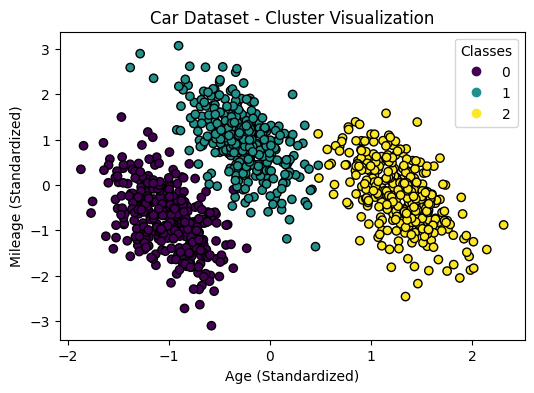

In [10]:


fig, ax = plt.subplots(figsize=(6, 4))

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    edgecolor="black"
)

ax.set(
    title="Car Dataset - Cluster Visualization",
    xlabel="Age (Standardized)",
    ylabel="Mileage (Standardized)"
)

ax.legend(*scatter.legend_elements(), title="Classes")

plt.show()



# ================================
# 4️⃣ Classifier Training
# ================================

In [11]:


# Multinomial Logistic Regression
logistic_regression_multinomial = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
).fit(X, y)

# One-vs-Rest Logistic Regression
logistic_regression_ovr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
).fit(X, y)

# Accuracy
accuracy_multinomial = logistic_regression_multinomial.score(X, y)
accuracy_ovr = logistic_regression_ovr.score(X, y)

print(f"Multinomial Accuracy: {accuracy_multinomial:.4f}")
print(f"One-vs-Rest Accuracy: {accuracy_ovr:.4f}")



Multinomial Accuracy: 0.9930
One-vs-Rest Accuracy: 0.9700


c:\Users\MUDASSAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# ================================
# 5️⃣ Decision Boundary Visualization
# ================================

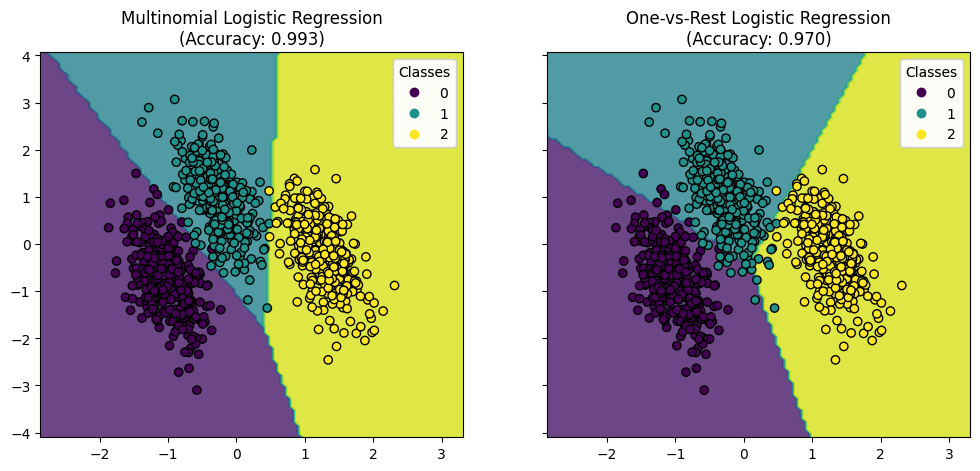

In [12]:


fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), sharex=True, sharey=True
)

for model, title, ax in [
    (
        logistic_regression_multinomial,
        f"Multinomial Logistic Regression\n(Accuracy: {accuracy_multinomial:.3f})",
        ax1,
    ),
    (
        logistic_regression_ovr,
        f"One-vs-Rest Logistic Regression\n(Accuracy: {accuracy_ovr:.3f})",
        ax2,
    ),
]:
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        ax=ax,
        response_method="predict",
        alpha=0.8,
    )

    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="k"
    )

    legend = ax.legend(*scatter.legend_elements(), title="Classes")
    ax.add_artist(legend)

    ax.set_title(title)

plt.show()

# ================================
# Simple Conclusion
# ================================

1. Both models perform very well.

2. Multinomial Logistic Regression performs slightly better and produces cleaner decision boundaries.

3. That is why its accuracy is 99.5% vs 97.6%.